In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_PATH = Path.cwd().parent
PROCESSED_PATH = PROJECT_PATH / "data" / "processed"

print("Project path:", PROJECT_PATH)
print("Processed data path:", PROCESSED_PATH)

Project path: c:\Users\User\Desktop\foresight
Processed data path: c:\Users\User\Desktop\foresight\data\processed


In [2]:
sales = pd.read_csv(
    PROCESSED_PATH / "sales_daily_clean.csv",
    parse_dates=["Date"]
)

calendar = pd.read_csv(
    PROCESSED_PATH / "calendar_clean.csv",
    parse_dates=["date"]
)

inventory = pd.read_csv(
    PROCESSED_PATH / "inventory_snapshots_clean.csv",
    parse_dates=["Snapshot_Date"]
)

sku_master = pd.read_csv(
    PROCESSED_PATH / "sku_master_clean.csv"
)

promotions = pd.read_csv(
    PROJECT_PATH / "data" / "raw" / "promotions.csv",
    parse_dates=["start_date", "end_date"]
)

print("Sales:", sales.shape)
print("Calendar:", calendar.shape)
print("Inventory:", inventory.shape)
print("SKU Master:", sku_master.shape)
print("Promotions:", promotions.shape)

Sales: (36550, 7)
Calendar: (731, 11)
Inventory: (4800, 9)
SKU Master: (5000, 8)
Promotions: (100, 8)


In [3]:
# Overall demand overview

total_units = sales["Units_Sold"].sum()
total_revenue = sales["Revenue"].sum()
active_skus = sales["SKU_Standard"].nunique()
start_date = sales["Date"].min()
end_date = sales["Date"].max()
total_days = sales["Date"].nunique()
avg_daily_units = sales.groupby("Date")["Units_Sold"].sum().mean()

print("FORESIGHT DEMAND OVERVIEW")
print("=" * 60)
print(f"Sales period       : {start_date.date()} to {end_date.date()}")
print(f"Number of days     : {total_days}")
print(f"Active SKUs        : {active_skus}")
print(f"Total units sold   : {total_units:,.0f}")
print(f"Total revenue      : ₹{total_revenue:,.2f}")
print(f"Average daily units: {avg_daily_units:,.2f}")

FORESIGHT DEMAND OVERVIEW
Sales period       : 2024-01-01 to 2025-12-31
Number of days     : 731
Active SKUs        : 50
Total units sold   : 511,810
Total revenue      : ₹3,096,056,707.22
Average daily units: 700.15


In [4]:
# Daily sales coverage

daily_coverage = (
    sales.groupby("Date")
    .agg(
        SKU_Records=("SKU_Standard", "nunique"),
        Units_Sold=("Units_Sold", "sum"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
)

print("Daily coverage:")
print(f"Minimum SKU records in a day: {daily_coverage['SKU_Records'].min()}")
print(f"Maximum SKU records in a day: {daily_coverage['SKU_Records'].max()}")
print(f"Average SKU records per day : {daily_coverage['SKU_Records'].mean():.2f}")

print("\nDays with fewer than 50 SKU records:",
      (daily_coverage["SKU_Records"] < 50).sum())

Daily coverage:
Minimum SKU records in a day: 50
Maximum SKU records in a day: 50
Average SKU records per day : 50.00

Days with fewer than 50 SKU records: 0


In [5]:
# SKU-level demand summary

sku_demand = (
    sales.groupby("SKU_Standard")
    .agg(
        Total_Units=("Units_Sold", "sum"),
        Total_Revenue=("Revenue", "sum"),
        Average_Daily_Units=("Units_Sold", "mean"),
        Demand_Std=("Units_Sold", "std")
    )
    .reset_index()
)

top_10_skus = sku_demand.sort_values(
    "Total_Units", ascending=False
).head(10)

bottom_10_skus = sku_demand.sort_values(
    "Total_Units", ascending=True
).head(10)

print("TOP 10 SKUs BY TOTAL UNITS SOLD")
display(top_10_skus)

print("\nBOTTOM 10 SKUs BY TOTAL UNITS SOLD")
display(bottom_10_skus)

TOP 10 SKUs BY TOTAL UNITS SOLD


,SKU_Standard,Total_Units,Total_Revenue,Average_Daily_Units,Demand_Std
11,SKU00012,19067,1.673962e+08,26.083447,6.999600
44,SKU00045,18612,1.428802e+08,25.461012,7.036270
17,SKU00018,18450,1.028663e+08,25.239398,6.532438
48,SKU00049,18373,9.596898e+07,25.134063,6.293600
36,SKU00037,18155,4.987941e+07,24.835841,6.433464
6,SKU00007,18129,9.271334e+07,24.800274,6.530103
26,SKU00027,17717,1.508886e+08,24.236662,6.321745
41,SKU00042,16616,1.528478e+08,22.730506,6.093777
25,SKU00026,16535,1.808853e+08,22.619699,6.433035
42,SKU00043,16276,1.423462e+08,22.265390,6.172466



BOTTOM 10 SKUs BY TOTAL UNITS SOLD


,SKU_Standard,Total_Units,Total_Revenue,Average_Daily_Units,Demand_Std
10,SKU00011,1951,2818336.56,2.668947,1.736744
24,SKU00025,1976,22838627.76,2.703146,1.696323
38,SKU00039,2300,16373585.00,3.146375,1.829491
14,SKU00015,2994,18599087.28,4.095759,2.196291
3,SKU00004,3380,23192106.60,4.623803,2.363984
29,SKU00030,3493,32951250.43,4.778386,2.279780
35,SKU00036,3508,19949996.00,4.798906,2.338317
27,SKU00028,4101,14288253.09,5.610123,2.541137
2,SKU00003,4214,34041661.22,5.764706,2.762154
49,SKU00050,4537,4004900.64,6.206566,2.806501


In [7]:
# Join SKU demand with product master information

sku_product_analysis = sku_demand.merge(
    sku_master[
        [
            "SKU_Standard",
            "sku_name",
            "category",
            "subcategory",
            "brand",
            "unit_price",
            "cost_price"
        ]
    ],
    on="SKU_Standard",
    how="left"
)

top_10_products = sku_product_analysis.sort_values(
    "Total_Units",
    ascending=False
).head(10)

display(
    top_10_products[
        [
            "SKU_Standard",
            "sku_name",
            "category",
            "subcategory",
            "brand",
            "Total_Units",
            "Total_Revenue",
            "Average_Daily_Units"
        ]
    ]
)

,SKU_Standard,sku_name,category,subcategory,brand,Total_Units,Total_Revenue,Average_Daily_Units
11,SKU00012,HomeStyle Vitamins & Supplements 1kg,Health & Wellness,Vitamins & Supplements,HomeStyle,19067,1.673962e+08,26.083447
44,SKU00045,SmartBuy Writing Instruments 1L,Stationery & Office,Writing Instruments,SmartBuy,18612,1.428802e+08,25.461012
17,SKU00018,PurePlus Chips & Crisps Small,Snacks & Confectionery,Chips & Crisps,PurePlus,18450,1.028663e+08,25.239398
48,SKU00049,CityFresh Oral Care 500ml,Personal Care,Oral Care,CityFresh,18373,9.596898e+07,25.134063
36,SKU00037,EverydayPlus Energy Drinks 100g,Beverages,Energy Drinks,EverydayPlus,18155,4.987941e+07,24.835841
6,SKU00007,GreenValley Energy Drinks Pack of 12,Beverages,Energy Drinks,GreenValley,18129,9.271334e+07,24.800274
26,SKU00027,TrueTaste Mobile Accessories Small,Electronics & Accessories,Mobile Accessories,TrueTaste,17717,1.508886e+08,24.236662
41,SKU00042,ValueChoice OTC Medicine Large,Health & Wellness,OTC Medicine,ValueChoice,16616,1.528478e+08,22.730506
25,SKU00026,PrimeCare Laundry Family Pack,Home Care,Laundry,PrimeCare,16535,1.808853e+08,22.619699
42,SKU00043,NovaFresh First Aid Pack of 6,Health & Wellness,First Aid,NovaFresh,16276,1.423462e+08,22.265390


In [8]:
category_demand = (
    sku_product_analysis
    .groupby("category")
    .agg(
        Total_Units=("Total_Units", "sum"),
        Total_Revenue=("Total_Revenue", "sum"),
        Average_Daily_Units=("Average_Daily_Units", "mean"),
        Number_of_SKUs=("SKU_Standard", "nunique")
    )
    .reset_index()
    .sort_values("Total_Units", ascending=False)
)

display(category_demand)

,category,Total_Units,Total_Revenue,Average_Daily_Units,Number_of_SKUs
9,Personal Care,79893,3.950818e+08,15.613250,7
1,Beverages,73801,3.344145e+08,12.619870,8
8,Home Care,64019,5.514266e+08,14.596215,6
6,Health & Wellness,56745,5.013857e+08,19.406635,4
3,Electronics & Accessories,52132,2.972679e+08,14.263201,5
11,Stationery & Office,43035,3.033364e+08,11.774282,5
0,Apparel & Footwear,33434,4.558872e+07,15.245782,3
2,Dairy & Bakery,32564,1.672751e+08,11.136799,4
4,Frozen Foods,23267,1.688096e+08,10.609667,3
7,Home & Kitchen,22032,1.727173e+08,15.069767,2


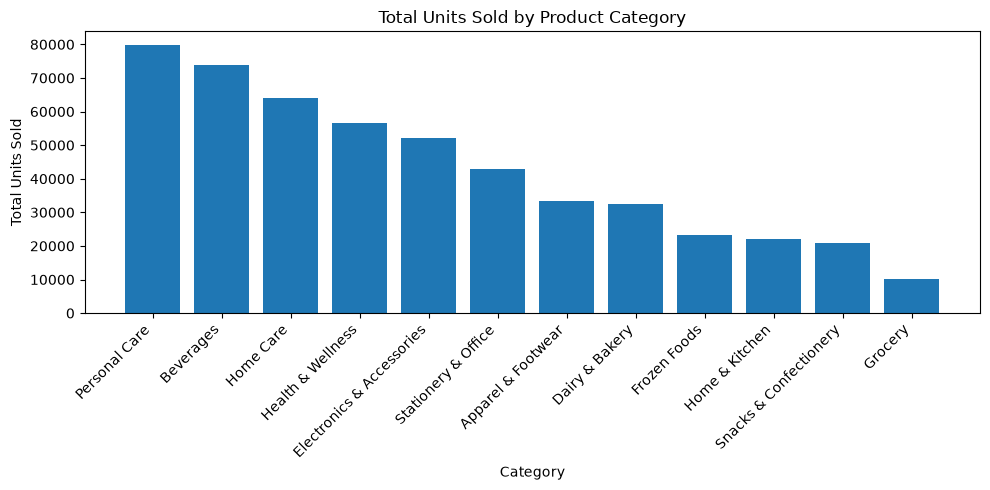

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    category_demand["category"],
    category_demand["Total_Units"]
)

plt.title("Total Units Sold by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [10]:
monthly_demand = (
    sales.assign(
        YearMonth=sales["Date"].dt.to_period("M").astype(str)
    )
    .groupby("YearMonth")
    .agg(
        Total_Units=("Units_Sold", "sum"),
        Total_Revenue=("Revenue", "sum")
    )
    .reset_index()
)

display(monthly_demand)

,YearMonth,Total_Units,Total_Revenue
0,2024-01,20961,1.271089e+08
1,2024-02,21333,1.288302e+08
2,2024-03,26791,1.617098e+08
3,2024-04,24177,1.465031e+08
4,2024-05,24402,1.476652e+08
5,2024-06,24506,1.483153e+08
6,2024-07,21118,1.272197e+08
7,2024-08,19351,1.177830e+08
8,2024-09,18723,1.131929e+08
9,2024-10,17173,1.040180e+08


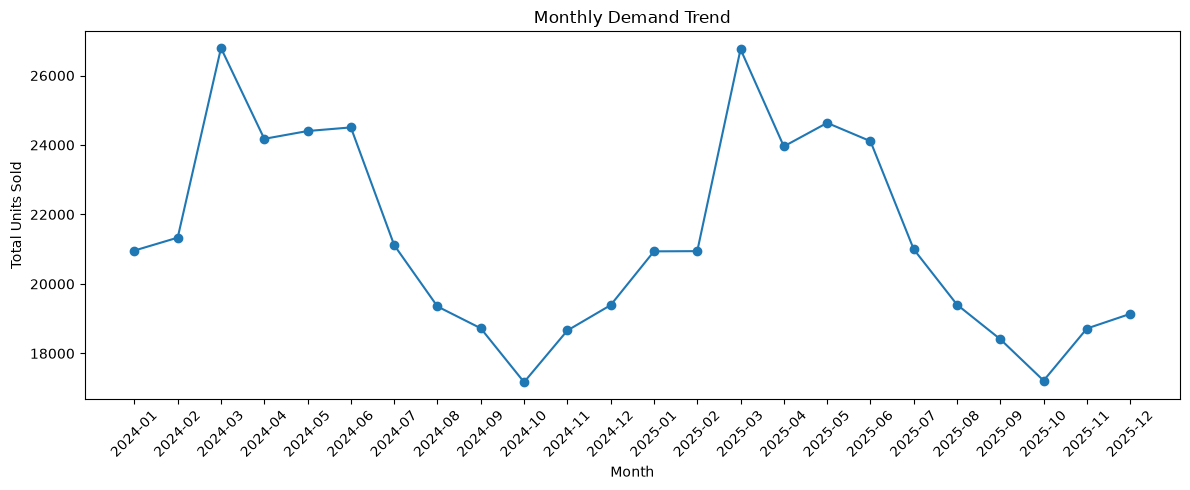

In [11]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_demand["YearMonth"],
    monthly_demand["Total_Units"],
    marker="o"
)

plt.title("Monthly Demand Trend")
plt.xlabel("Month")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [14]:
weekly_demand = (
    sales.assign(
        Day=sales["Date"].dt.day_name()
    )
    .groupby("Day")
    .agg(
        Total_Units=("Units_Sold", "sum"),
        Average_Daily_Units=("Units_Sold", "mean")
    )
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
    .reset_index()
)

display(weekly_demand)

,Day,Total_Units,Average_Daily_Units
0,Monday,68430,13.034286
1,Tuesday,68342,13.017524
2,Wednesday,68451,13.038286
3,Thursday,68193,13.114038
4,Friday,68567,13.185962
5,Saturday,84652,16.279231
6,Sunday,85175,16.379808


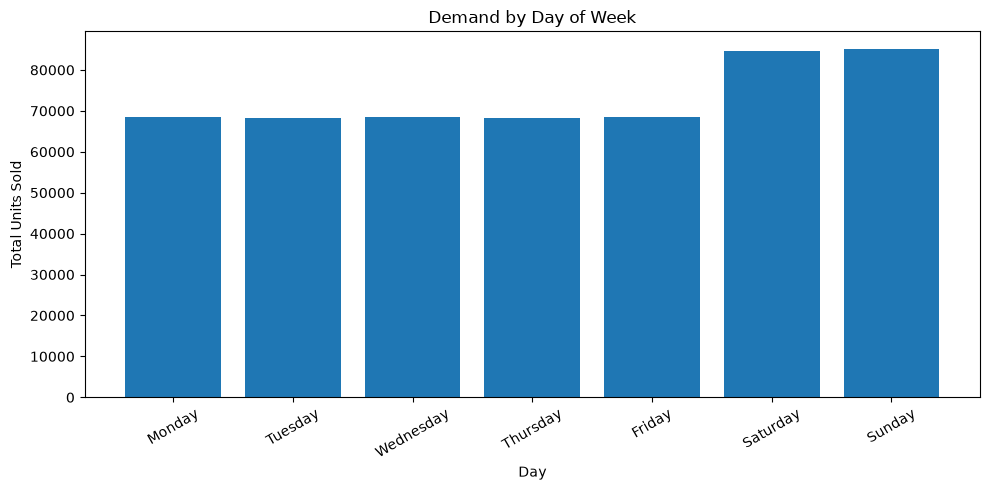

In [15]:
plt.figure(figsize=(10, 5))

plt.bar(
    weekly_demand["Day"],
    weekly_demand["Total_Units"]
)

plt.title("Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [16]:
promotion_demand = (
    sales.groupby("Promotion")
    .agg(
        Total_Units=("Units_Sold", "sum"),
        Average_Daily_Units=("Units_Sold", "mean"),
        Average_Revenue=("Revenue", "mean"),
        Number_of_Records=("SKU_Standard", "count")
    )
    .reset_index()
)

display(promotion_demand)

,Promotion,Total_Units,Average_Daily_Units,Average_Revenue,Number_of_Records
0,0,442011,13.475945,81550.078302,32800
1,1,69799,18.613067,112323.770379,3750


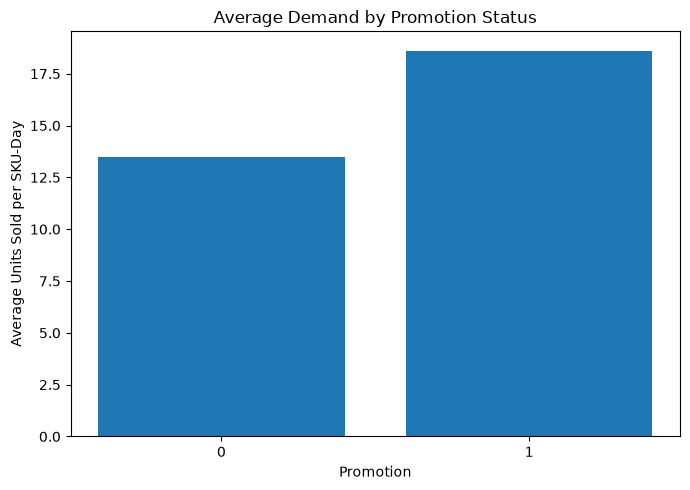

In [17]:
plt.figure(figsize=(7, 5))

plt.bar(
    promotion_demand["Promotion"].astype(str),
    promotion_demand["Average_Daily_Units"]
)

plt.title("Average Demand by Promotion Status")
plt.xlabel("Promotion")
plt.ylabel("Average Units Sold per SKU-Day")

plt.tight_layout()
plt.show()

In [18]:
promo_values = promotion_demand.set_index("Promotion")

if 0 in promo_values.index and 1 in promo_values.index:
    non_promo = promo_values.loc[0, "Average_Daily_Units"]
    promo = promo_values.loc[1, "Average_Daily_Units"]

    uplift_pct = ((promo - non_promo) / non_promo) * 100

    print(f"Average demand without promotion: {non_promo:.2f}")
    print(f"Average demand with promotion   : {promo:.2f}")
    print(f"Promotion demand difference     : {uplift_pct:.2f}%")
else:
    print("Promotion values found:", promotion_demand["Promotion"].unique())

Average demand without promotion: 13.48
Average demand with promotion   : 18.61
Promotion demand difference     : 38.12%


In [19]:
demand_variability = (
    sku_demand[
        [
            "SKU_Standard",
            "Average_Daily_Units",
            "Demand_Std"
        ]
    ]
    .copy()
)

demand_variability["Coefficient_of_Variation"] = (
    demand_variability["Demand_Std"] /
    demand_variability["Average_Daily_Units"]
)

high_variability_skus = (
    demand_variability
    .sort_values("Coefficient_of_Variation", ascending=False)
    .head(10)
)

display(high_variability_skus)

,SKU_Standard,Average_Daily_Units,Demand_Std,Coefficient_of_Variation
10,SKU00011,2.668947,1.736744,0.650723
24,SKU00025,2.703146,1.696323,0.627536
38,SKU00039,3.146375,1.829491,0.581460
14,SKU00015,4.095759,2.196291,0.536235
3,SKU00004,4.623803,2.363984,0.511264
35,SKU00036,4.798906,2.338317,0.487260
2,SKU00003,5.764706,2.762154,0.479149
29,SKU00030,4.778386,2.279780,0.477102
27,SKU00028,5.610123,2.541137,0.452956
49,SKU00050,6.206566,2.806501,0.452183


In [20]:
print("Demand variability summary")
print("=" * 50)

print(
    f"Average coefficient of variation: "
    f"{demand_variability['Coefficient_of_Variation'].mean():.3f}"
)

print(
    f"Highest coefficient of variation: "
    f"{demand_variability['Coefficient_of_Variation'].max():.3f}"
)

Demand variability summary
Average coefficient of variation: 0.358
Highest coefficient of variation: 0.651


In [21]:
inventory_analysis = inventory.copy()

inventory_analysis["Below_Reorder_Point"] = (
    inventory_analysis["Current_Stock"] <
    inventory_analysis["Reorder_Point"]
)

inventory_analysis["Below_Safety_Stock"] = (
    inventory_analysis["Current_Stock"] <
    inventory_analysis["Safety_Stock"]
)

inventory_summary = (
    inventory_analysis
    .agg(
        Total_Records=("SKU_Standard", "count"),
        Below_Reorder_Point=("Below_Reorder_Point", "sum"),
        Below_Safety_Stock=("Below_Safety_Stock", "sum")
    )
)

display(inventory_summary)

,SKU_Standard,Below_Reorder_Point,Below_Safety_Stock
Total_Records,4800.0,NaN,NaN
Below_Reorder_Point,NaN,1370.0,NaN
Below_Safety_Stock,NaN,NaN,128.0


In [22]:
print(
    "Percentage below reorder point: "
    f"{inventory_analysis['Below_Reorder_Point'].mean() * 100:.2f}%"
)

print(
    "Percentage below safety stock: "
    f"{inventory_analysis['Below_Safety_Stock'].mean() * 100:.2f}%"
)

Percentage below reorder point: 28.54%
Percentage below safety stock: 2.67%
